In [ ]:
import numpy as np
from matplotlib import pyplot as plt

import keras

In [ ]:
mnist = keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [ ]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

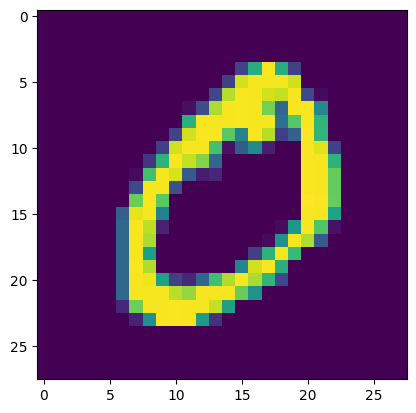

In [ ]:
plt.imshow(x_train[1])

In [ ]:
np.unique(y_train, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949]))

In [ ]:
np.unique(y_test, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([ 980, 1135, 1032, 1010,  982,  892,  958, 1028,  974, 1009]))

In [ ]:
np.max(x_train), np.max(x_test)

(np.uint8(255), np.uint8(255))

In [ ]:
np.min(x_train), np.min(x_test)

(np.uint8(0), np.uint8(0))

In [ ]:
x_train = x_train / 255
x_test = x_test / 255

In [ ]:
28 * 28

784

In [ ]:
model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=(28, 28)))
model.add(keras.layers.Dense(128, activation="relu"))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(10, activation="relu"))
model.add(keras.layers.Dense(1))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,781 (397.58 KB)

 Trainable params: 101,781 (397.58 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
loss = keras.losses.MeanSquaredError()
opt = keras.optimizers.Adam()

In [ ]:
model.compile(optimizer=opt, loss=loss, metrics=["accuracy"])

In [ ]:
history = model.fit(x_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.1599 - loss: 3.3068
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.1937 - loss: 1.1537
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.2000 - loss: 0.8866
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.1954 - loss: 0.7268
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.1994 - loss: 0.6149


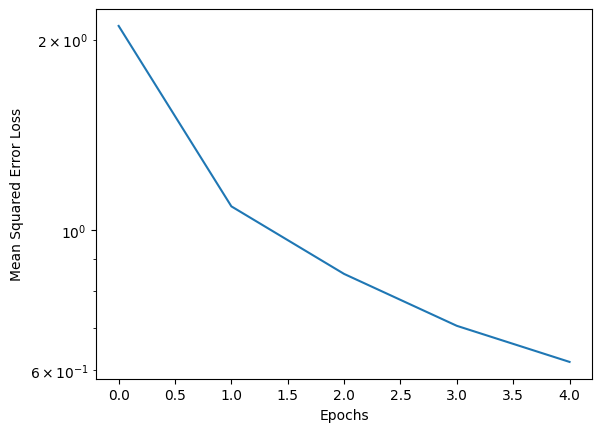

In [ ]:
plt.plot(history.history["loss"])
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error Loss")
plt.yscale("log")
plt.show()

In [ ]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2040 - loss: 0.7189


[0.6213877201080322, 0.2071000039577484]

In [ ]:
model2 = keras.models.Sequential()
model2.add(keras.layers.Flatten(input_shape=(28, 28)))
model2.add(keras.layers.Dense(128, activation="relu"))
model2.add(keras.layers.Dropout(0.2))
model2.add(keras.layers.Dense(10, activation="sigmoid"))
model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
loss = keras.losses.SparseCategoricalCrossentropy()
opt = keras.optimizers.Adam()
model2.compile(optimizer=opt, loss=loss, metrics=["accuracy"])
history2 = model2.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=5,
    )

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9796 - loss: 0.0626 - val_accuracy: 0.9847 - val_loss: 0.0469
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9832 - loss: 0.0532 - val_accuracy: 0.9841 - val_loss: 0.0505
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9840 - loss: 0.0494 - val_accuracy: 0.9860 - val_loss: 0.0466
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9861 - loss: 0.0451 - val_accuracy: 0.9849 - val_loss: 0.0500
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9875 - loss: 0.0391 - val_accuracy: 0.9819 - val_loss: 0.0596


In [ ]:
model2.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9760 - loss: 0.0910


[0.07453358918428421, 0.9790999889373779]

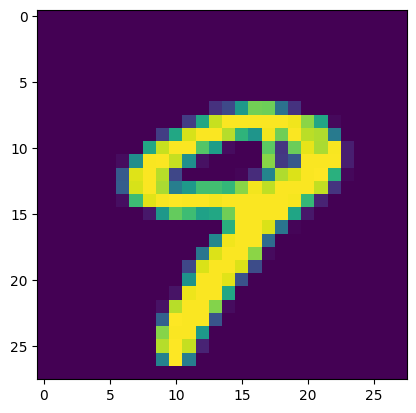

In [ ]:
plt.imshow(x_test[9])

In [ ]:
model2.predict(x_test[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


array([[3.7477857e-03, 5.6324266e-06, 8.7741189e-02, 9.9106961e-01,
        5.8886294e-12, 2.1483251e-03, 9.7341177e-11, 9.9999791e-01,
        7.9574838e-04, 1.4338723e-01],
       [8.8805443e-01, 1.1004906e-01, 9.9999988e-01, 8.1626154e-02,
        1.4299948e-13, 5.9068944e-02, 3.7214526e-05, 2.3261102e-13,
        9.3125214e-04, 5.4975100e-13],
       [4.6186683e-06, 9.9994880e-01, 3.5374176e-02, 6.3315674e-04,
        2.1364149e-03, 3.9432468e-03, 9.8203830e-03, 6.7639112e-01,
        1.1976844e-01, 1.3187177e-04],
       [9.9999499e-01, 8.0859456e-05, 8.6318547e-01, 4.4149112e-02,
        1.7743453e-04, 2.4342275e-01, 2.3066477e-01, 1.2527759e-02,
        1.3574710e-03, 1.0270228e-03],
       [2.9020945e-03, 8.8119583e-07, 2.5272368e-02, 8.2820798e-06,
        9.9997330e-01, 4.2317610e-04, 1.7103850e-03, 4.3972826e-01,
        4.9737361e-03, 9.7973913e-01]], dtype=float32)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


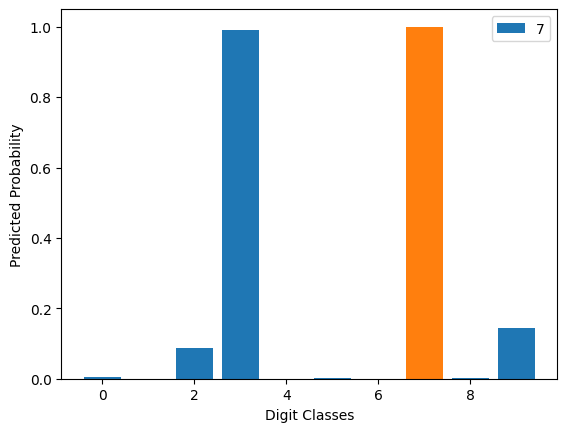

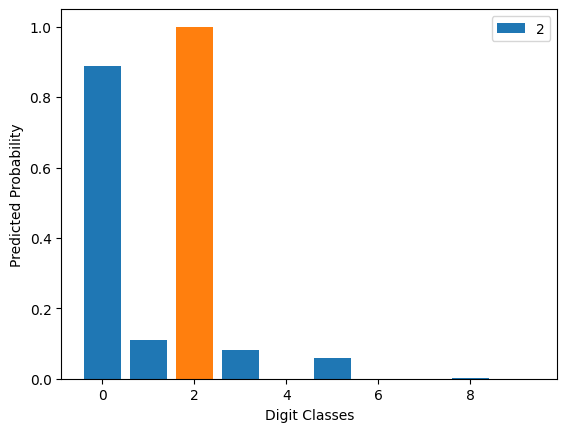

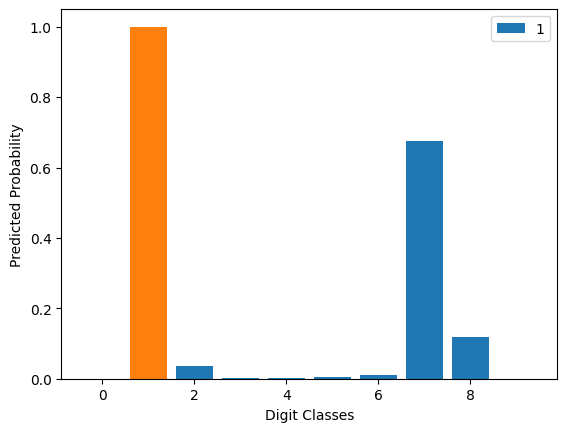

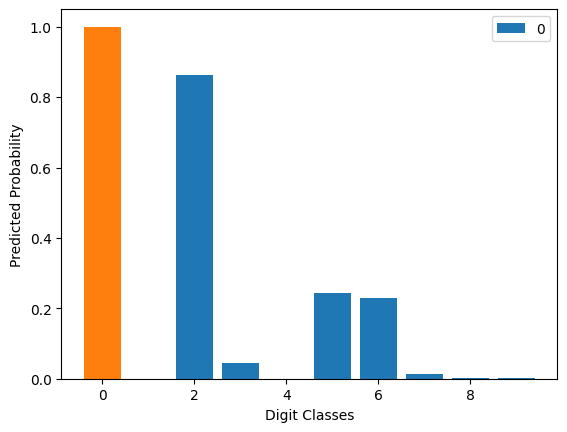

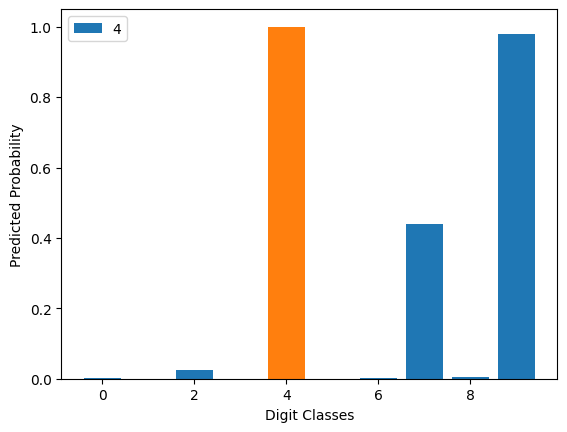

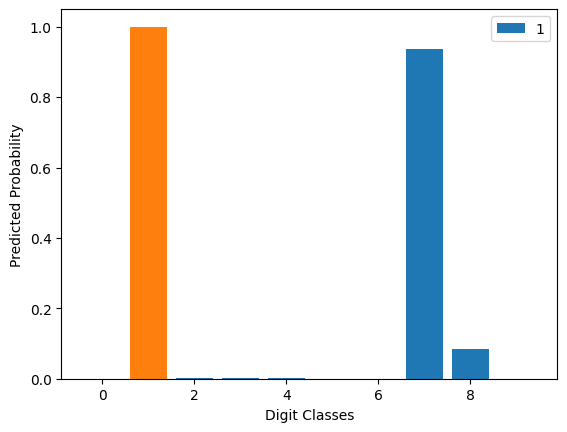

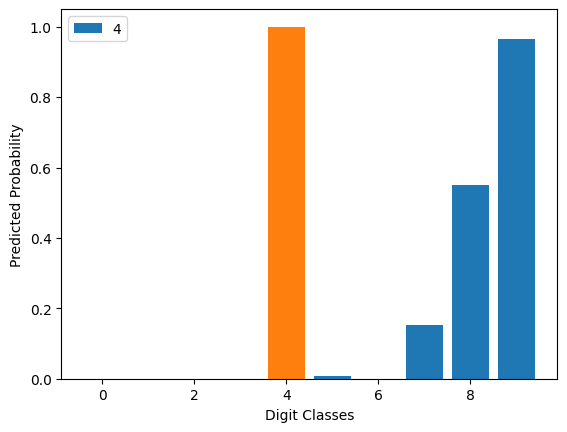

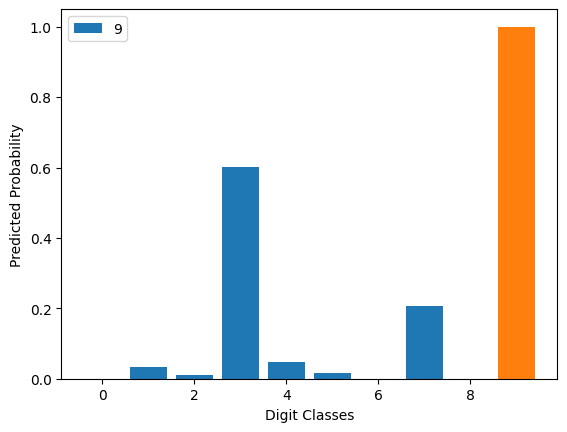

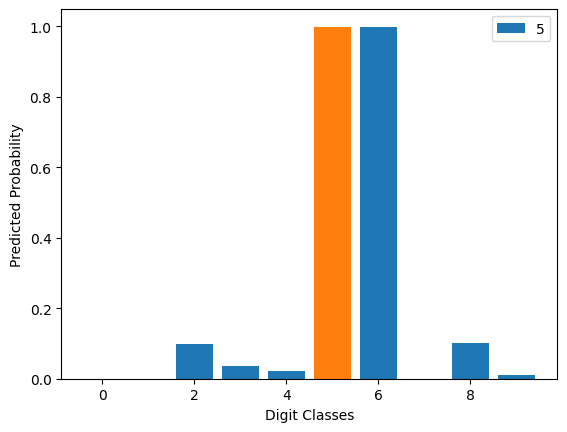

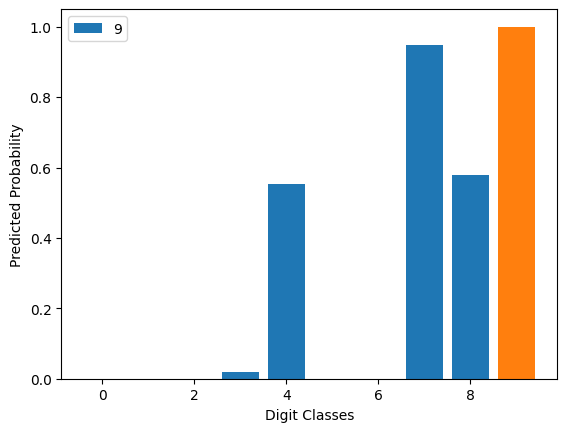

In [ ]:
for i, prediction in enumerate(model2.predict(x_test[:10])):
    plt.bar(range(10), prediction, label=y_test[i])
    plt.bar(range(10)[np.argmax(prediction)], np.max(prediction))
    plt.legend()
    plt.xlabel("Digit Classes")
    plt.ylabel("Predicted Probability")
    plt.show()
